# EuroSAT — Exploratory Data Analysis (EDA)

Before building any model it is worth **understanding the data**. This notebook explores the raw EuroSAT (Sentinel-2) dataset and answers:

1. What classes exist and what do they mean?
2. How many images per class — is the dataset balanced?
3. What is the image format (size, channels, dtype, value range)?
4. What do images from each class look like?
5. How are pixel intensities distributed across RGB channels?

Each finding is connected back to a concrete decision in the training pipeline.

In [1]:
%matplotlib inline
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.datasets import EuroSAT

# Robust to being run from the repo root or from notebooks/.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

ds = EuroSAT(root=str(ROOT / "data" / "raw"), download=False)
labels = [label for _, label in ds.samples]
print(f"{len(ds)} images, {len(ds.classes)} classes")

27000 images, 10 classes


## 1. Classes and their meaning

EuroSAT labels are **land use / land cover** categories.

In [2]:
CLASS_DESCRIPTIONS = {
    "AnnualCrop": "Annual crops (e.g. cereals, seasonal)",
    "Forest": "Forest / dense trees",
    "HerbaceousVegetation": "Herbaceous vegetation (shrubs, grasses)",
    "Highway": "Highways / major roads",
    "Industrial": "Industrial areas",
    "Pasture": "Pasture / grazing land",
    "PermanentCrop": "Permanent crops (e.g. orchards, vineyards)",
    "Residential": "Residential areas",
    "River": "Rivers",
    "SeaLake": "Sea / lakes",
}

counts = Counter(labels)
table = pd.DataFrame({
    "class": ds.classes,
    "description": [CLASS_DESCRIPTIONS[c] for c in ds.classes],
    "images": [counts[i] for i in range(len(ds.classes))],
})
table["%"] = (100 * table["images"] / len(ds)).round(1)
table

,class,description,images,%
0,AnnualCrop,"Annual crops (e.g. cereals, seasonal)",3000,11.1
1,Forest,Forest / dense trees,3000,11.1
2,HerbaceousVegetation,"Herbaceous vegetation (shrubs, grasses)",3000,11.1
3,Highway,Highways / major roads,2500,9.3
4,Industrial,Industrial areas,2500,9.3
5,Pasture,Pasture / grazing land,2000,7.4
6,PermanentCrop,"Permanent crops (e.g. orchards, vineyards)",2500,9.3
7,Residential,Residential areas,3000,11.1
8,River,Rivers,2500,9.3
9,SeaLake,Sea / lakes,3000,11.1


## 2. Class distribution — is it balanced?

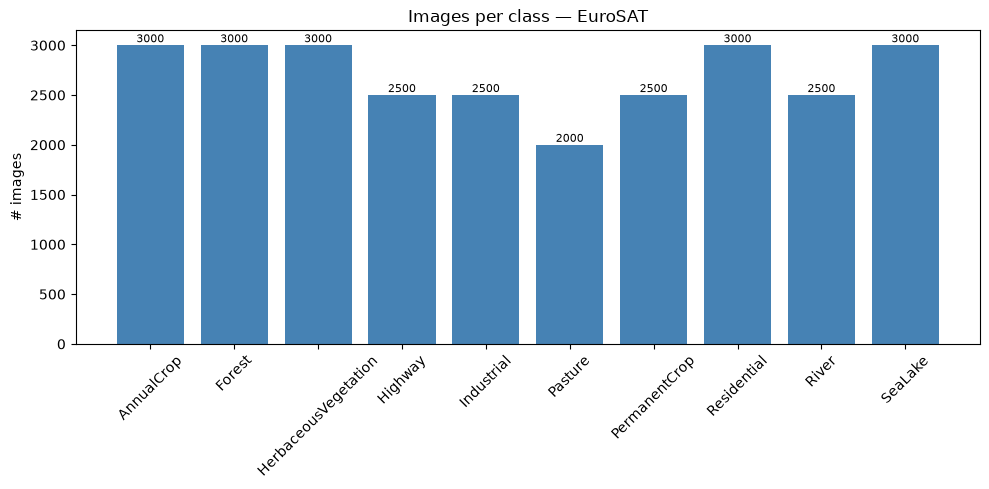

Imbalance ratio (largest/smallest class): 1.50x


In [3]:
values = [counts[i] for i in range(len(ds.classes))]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ds.classes, values, color="steelblue")
ax.set_title("Images per class — EuroSAT")
ax.set_ylabel("# images")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(values):
    ax.text(i, v + 30, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

imbalance = max(values) / min(values)
print(f"Imbalance ratio (largest/smallest class): {imbalance:.2f}x")

**Finding:** the dataset is *slightly* imbalanced (1.5×, Pasture is the smallest at 2000).

**Pipeline link:** this justifies (a) the **stratified split** that keeps class proportions across train/val/test, and (b) reporting **macro-F1**, which weights every class equally regardless of size.

## 3. Image format

In [4]:
img0, _ = ds[0]
arr0 = np.asarray(img0)
print(f"Shape: {arr0.shape}  (height, width, channels)")
print(f"dtype: {arr0.dtype}   value range: [{arr0.min()}, {arr0.max()}]")

Shape: (64, 64, 3)  (height, width, channels)
dtype: uint8   value range: [82, 204]


**Finding:** images are **64×64 RGB, uint8 (0–255)**.

**Pipeline link:** this justifies the **resize 64→224** (to match ImageNet-pretrained backbones) and the `ToDtype(scale=True)` step (0–255 → 0–1).

## 4. Sample images per class

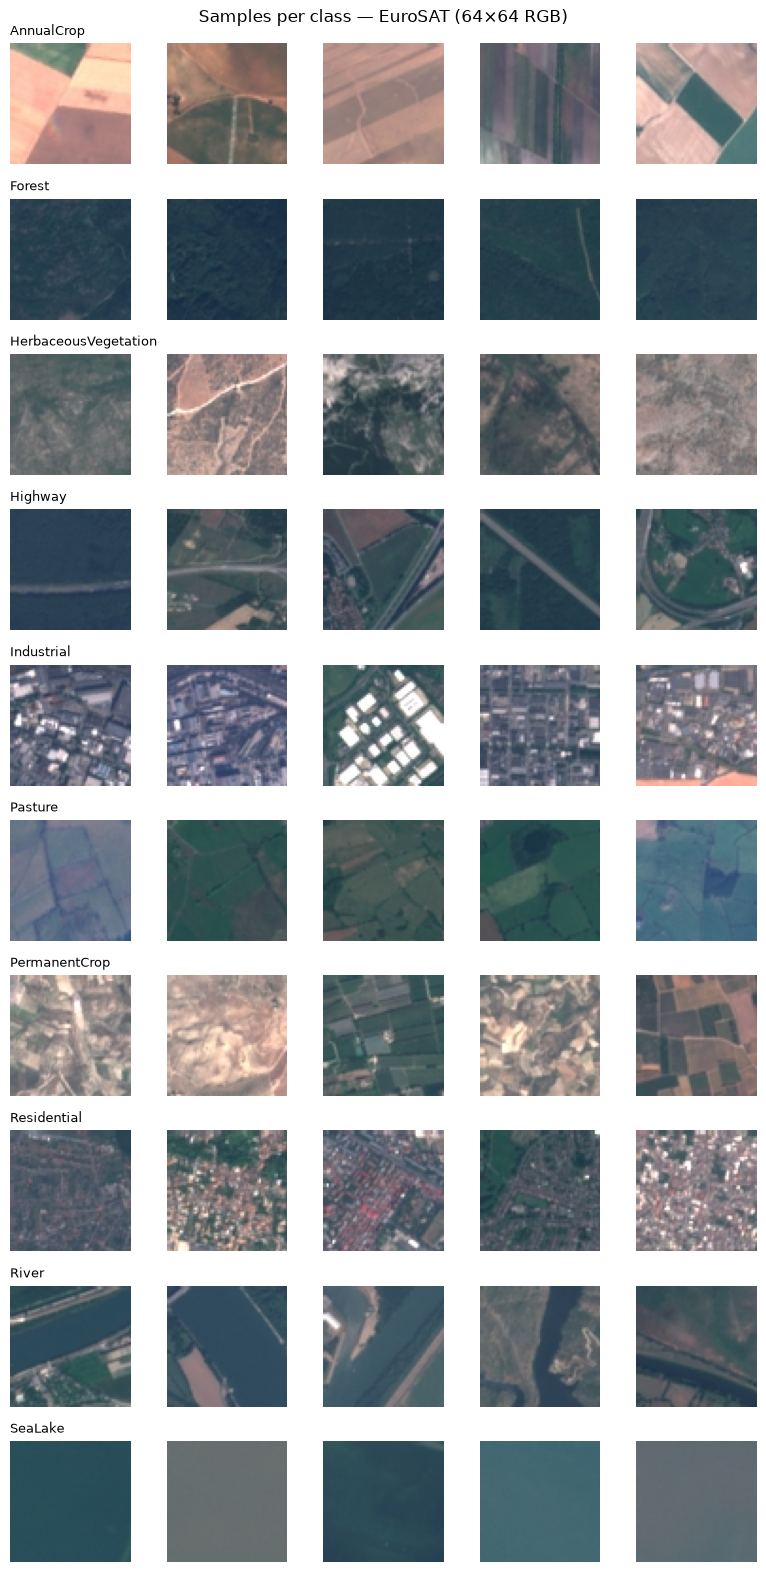

In [5]:
rng = np.random.default_rng(42)
by_class = {i: [] for i in range(len(ds.classes))}
for idx, (_, label) in enumerate(ds.samples):
    by_class[label].append(idx)

n_per = 5
fig, axes = plt.subplots(len(ds.classes), n_per, figsize=(n_per * 1.6, len(ds.classes) * 1.6))
for r, name in enumerate(ds.classes):
    for c, idx in enumerate(rng.choice(by_class[r], size=n_per, replace=False)):
        axes[r, c].imshow(ds[idx][0])
        axes[r, c].axis("off")
    axes[r, 0].set_title(name, loc="left", fontsize=9)
plt.suptitle("Samples per class — EuroSAT (64×64 RGB)")
plt.tight_layout()
plt.show()

**Finding:** classes are visually distinct (Forest = uniform dark green, Residential = geometric rooftops, SeaLake = flat blue), but some are easy to confuse (the vegetation classes: AnnualCrop / HerbaceousVegetation / Pasture / PermanentCrop).

**Pipeline link:** these confusable classes are exactly where the trained model's residual errors appear in the confusion matrix — and they motivate satellite-appropriate augmentation (flips/rotations, since there is no canonical orientation).

## 5. Pixel intensity distribution per channel

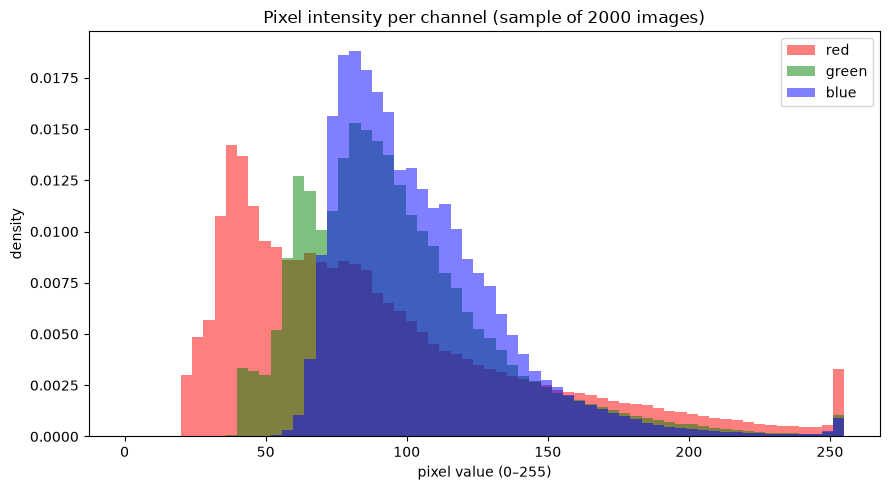

Per-channel mean/std (0–1 scale):
  R: mean=0.348  std=0.206
  G: mean=0.383  std=0.140


  B: mean=0.410  std=0.118


In [6]:
sample_idx = rng.choice(len(ds), size=min(2000, len(ds)), replace=False)
pixels = np.stack([np.asarray(ds[i][0]) for i in sample_idx])  # (N, 64, 64, 3)

fig, ax = plt.subplots(figsize=(9, 5))
for ch, color in zip(range(3), ["red", "green", "blue"]):
    ax.hist(pixels[..., ch].ravel(), bins=64, range=(0, 255), color=color, alpha=0.5, density=True, label=color)
ax.set_title("Pixel intensity per channel (sample of 2000 images)")
ax.set_xlabel("pixel value (0–255)")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

print("Per-channel mean/std (0–1 scale):")
for ch, name in zip(range(3), ["R", "G", "B"]):
    vals = pixels[..., ch] / 255.0
    print(f"  {name}: mean={vals.mean():.3f}  std={vals.std():.3f}")

**Finding:** the channels are not centered like ordinary photos — red is darker (peak ~40), blue/green brighter. EuroSAT per-channel means are ~R=0.35, G=0.38, B=0.41.

**Pipeline link:** these differ from the ImageNet stats (R=0.485, G=0.456, B=0.406) we use for normalization. That is **why normalized EuroSAT data is not centered at 0** — expected behaviour when reusing an ImageNet-pretrained backbone. If we trained from scratch, we would normalize with *these* EuroSAT statistics instead.

## Conclusions

- **10 land-use classes**, 27,000 RGB 64×64 Sentinel-2 patches.
- **Mildly imbalanced** (1.5×) → stratified split + macro-F1.
- **uint8, 0–255** → scale to [0,1] + resize to 224 for pretrained backbones.
- **Channel statistics differ from ImageNet** → explains the normalization behaviour; informs the choice between ImageNet vs. dataset-specific stats.
- **Some classes are visually similar** → expected confusions, addressed with augmentation and diagnosed via the confusion matrix.

EDA turned implicit assumptions into evidence-based decisions — the foundation of a trustworthy pipeline.